In [3]:
import shutil

# Extracts the archive into a folder named 'destination_folder'
shutil.unpack_archive('Images.zip', 'Data')


In [7]:
#Setting file paths

DATASET_PATH = "/voc/work/Capstone1/Data"

IMAGES_PATH = DATASET_PATH + "/Images"
LABEL_PATH = DATASET_PATH + "/labels.csv"

In [8]:
import os

print(os.path.exists(IMAGES_PATH))
print(os.path.exists(LABEL_PATH))

True
True


**Data Exploration**

In [45]:
import pandas as pd

labels = pd.read_csv(
    LABEL_PATH,
    header=None,
    names=[
        "image_id",
        "class_name",
        "xmin",
        "ymin",
        "xmax",
        "ymax"
    ]
)

labels.head()

,image_id,class_name,xmin,ymin,xmax,ymax
0,0,pickup_truck,213,34,255,50
1,0,car,194,78,273,122
2,0,car,155,27,183,35
3,0,articulated_truck,43,25,109,55
4,0,car,106,32,124,45


In [46]:
existing_ids = {
    int(os.path.splitext(f)[0])
    for f in os.listdir(IMAGES_PATH)
}

labels = labels[labels["image_id"].isin(existing_ids)].copy()

print(labels.shape)

(17967, 6)


In [47]:
print("Rows:", labels.shape[0])
print("Columns:", labels.shape[1])

Rows: 17967
Columns: 6


In [48]:
labels.columns

Index(['image_id', 'class_name', 'xmin', 'ymin', 'xmax', 'ymax'], dtype='object')

In [49]:
#Number of unique images
labels['image_id'].nunique()

5626

In [50]:
#Number of vehicle classes
labels['class_name'].nunique()

11

In [51]:
sorted(labels['class_name'].unique())

['articulated_truck',
 'bicycle',
 'bus',
 'car',
 'motorcycle',
 'motorized_vehicle',
 'non-motorized_vehicle',
 'pedestrian',
 'pickup_truck',
 'single_unit_truck',
 'work_van']

In [52]:
#frequency of each class
labels['class_name'].value_counts()

car                      12076
pickup_truck              2136
motorized_vehicle         1295
bus                        561
work_van                   462
articulated_truck          461
pedestrian                 340
single_unit_truck          303
bicycle                    130
non-motorized_vehicle      108
motorcycle                  95
Name: class_name, dtype: int64

In [53]:
#Objects per image
labels.groupby("image_id").size().describe()

count    5626.000000
mean        3.193566
std         2.951104
min         1.000000
25%         1.000000
50%         2.000000
75%         4.000000
max        27.000000
dtype: float64

In [54]:
images = sorted(os.listdir(IMAGES_PATH))
#checking image names
print(len(images))
print(images[:10])

5626
['00000000.jpg', '00000001.jpg', '00000002.jpg', '00000003.jpg', '00000004.jpg', '00000005.jpg', '00000006.jpg', '00000007.jpg', '00000008.jpg', '00000009.jpg']


In [55]:
#checking image sizes
from PIL import Image

img = Image.open(os.path.join(IMAGES_PATH, images[0]))

print(img.size)

(342, 228)


(-0.5, 341.5, 227.5, -0.5)

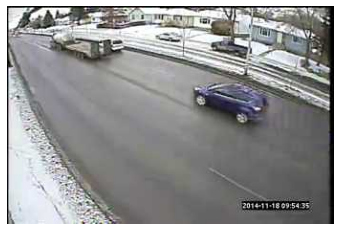

In [59]:
#displaying one image
import matplotlib.pyplot as plt

plt.imshow(img)
plt.axis("off")

**Visualize Bounding Boxes**

In [61]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import os

def show_image(image_id):

    image_path = os.path.join(
        IMAGES_PATH,
        f"{image_id:08d}.jpg"
    )

    img = Image.open(image_path)

    fig, ax = plt.subplots(figsize=(10,6))
    ax.imshow(img)

    objects = labels[labels["image_id"] == image_id]

    for _, row in objects.iterrows():

        xmin = row["xmin"]
        ymin = row["ymin"]
        xmax = row["xmax"]
        ymax = row["ymax"]

        rect = patches.Rectangle(
            (xmin, ymin),
            xmax-xmin,
            ymax-ymin,
            linewidth=2,
            edgecolor="red",
            facecolor="none"
        )

        ax.add_patch(rect)

        ax.text(
            xmin,
            ymin-2,
            row["class_name"],
            color="yellow",
            fontsize=8,
            backgroundcolor="black"
        )

    plt.axis("off")
    plt.show()

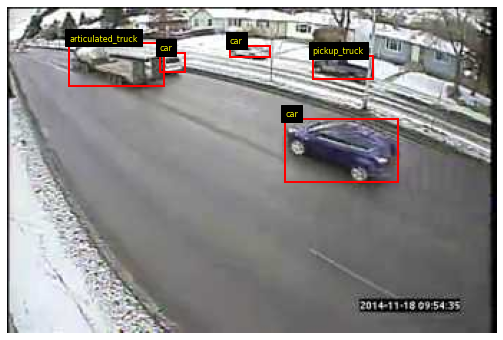

In [62]:
show_image(0)

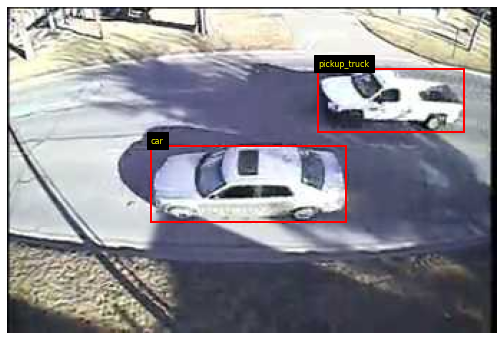

In [64]:
show_image(25)

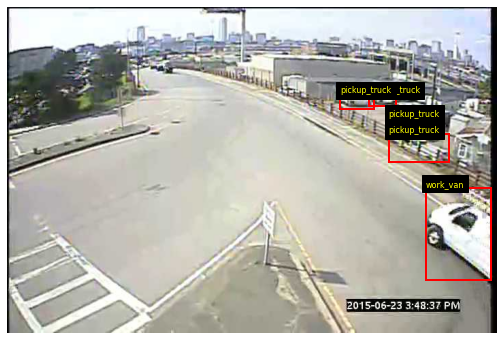

In [65]:
show_image(50)

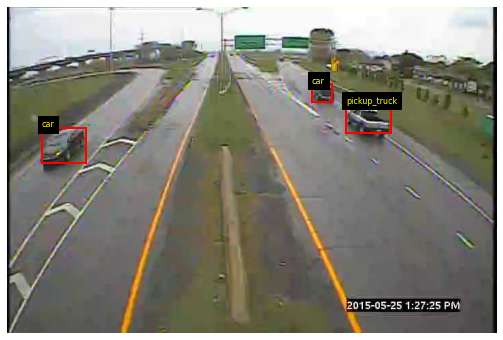

In [67]:
show_image(75)

The images all have boxes around them showing that the annotations, class labels, are correct.

In [68]:
labels.to_csv(
    os.path.join(DATASET_PATH, "labels_filtered.csv"),
    index=False
)

In [69]:
classes = sorted(labels["class_name"].unique())

class_to_id = {
    cls: idx
    for idx, cls in enumerate(classes)
}

print(class_to_id)

{'articulated_truck': 0, 'bicycle': 1, 'bus': 2, 'car': 3, 'motorcycle': 4, 'motorized_vehicle': 5, 'non-motorized_vehicle': 6, 'pedestrian': 7, 'pickup_truck': 8, 'single_unit_truck': 9, 'work_van': 10}


In [72]:
import json
from pathlib import Path

PROJECT_ROOT = Path("/voc/work/Capstone1")
DATA_PATH = PROJECT_ROOT / "Data"
with open(DATA_PATH / "class_mapping.json", "w") as f:
    json.dump(class_to_id, f, indent=4)